In [1]:
## This script is to plot MRMS and MERGIR -- 4 FOUR hourly
## Created by C. Bayu Risanto, S.J. (23 April 2026)
import warnings
warnings.filterwarnings('ignore')
import numpy as np
from numpy import matlib
import os
from os.path import exists
import xarray as xr
import dateutil.parser
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mplotcolors
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from copy import copy
import shapely.geometry as sgeom
from datetime import date, datetime, timedelta
# create ncfile opener
def read_mrms(link,ncfile):
    fname = link + ncfile
    ds = xr.open_dataset(fname)
    pcp = ds.PRECIP[:,:,:]
    return pcp
def read_latlon(link,ncfile):
    fname = link + ncfile
    ds = xr.open_dataset(fname)
    lat = ds.lat_0[:]
    lon = ds.lon_0[:]
    return lat,lon
def read_merg(link,ncfile):
    fname = link+ncfile
    ds = xr.open_dataset(fname)
    Tb = ds.to_array('Tb',None)
    tb = ds.Tb[0,:,:]
    return tb
def read_mrlon(link,ncfile):
    fname = link+ncfile
    ds = xr.open_dataset(fname)
    lon = ds.lon[:]
    lat = ds.lat[:]
    return lat,lon

In [2]:
## make LIST of datetime string here
datestrform = '%Y-%m-%dT%H'
date_st = datetime.strptime('2021-08-16T00',datestrform)
date_en = datetime.strptime('2021-08-16T09',datestrform)
dateList = [date_st.strftime(datestrform)]
date_time = date_st
while date_time < date_en:
    date_time += timedelta(hours=1)
    dateList.append(date_time.strftime(datestrform))
dateList = np.asarray(dateList)

In [3]:
## hourly precip and save the dates and hours
link_mrms = '/secchi/bayu/DATA/ARIZONA_PRO/OBS/MRMS/ncfiles/'
pcp_hr_al = []
for i in range(len(dateList)):
    yy = str(dateList[i]); YYYY = yy[0:4]
    mm = str(dateList[i]); MM = mm[5:7]
    dd = str(dateList[i]); DD = dd[8:10]
    hh = str(dateList[i]); HH = hh[11:13]
    nc_hour = 'MultiSensor_QPE_01H_Pass2_00.00_'+YYYY+MM+DD+'-'+HH+'0000_AZ.nc'
    if exists(link_mrms + nc_hour) == True:
        pcp_hr = read_mrms(link_mrms,nc_hour)
    else:
        pcp_hr = np.empty((902,1001)); pcp_hr[:] = np.nan
    pcp_hr_al.append(np.squeeze(pcp_hr))
al_pcp_hr = np.asarray(pcp_hr_al)

## read lat lon
lat_mrms,lon_mrms = read_latlon(link_mrms,nc_hour)
xlon_mrms = np.matlib.repmat(lon_mrms,len(lat_mrms),1) - 360.
xlat_mrms = np.matlib.repmat(lat_mrms,len(lon_mrms),1).T

In [4]:
## read data
link_merg = '/secchi/bayu/DATA/ARIZONA_PRO/OBS/MERGIR/'
ctt_hr_al = []
for i in range(len(dateList)):
    yy = str(dateList[i]); YYYY = yy[0:4]
    mm = str(dateList[i]); MM = mm[5:7]
    dd = str(dateList[i]); DD = dd[8:10]
    hh = str(dateList[i]); HH = hh[11:13]
    ncfile = 'merg_'+YYYY+MM+DD+HH+'_4km-pixel.nc4.nc4'
    if exists(link_merg + ncfile) == True:
        Tb = read_merg(link_merg,ncfile)
    else:
        Tb = np.empty((578,904)); Tb[:] = np.nan
    ctt_hr_al.append(np.squeeze(Tb))
al_ctt_hr = np.asarray(ctt_hr_al)

## read lat lon
lat_merg,lon_merg = read_mrlon(link_merg,ncfile)
xlon_merg = np.matlib.repmat(lon_merg,len(lat_merg),1)                             
xlat_merg = np.matlib.repmat(lat_merg,len(lon_merg),1).T

In [5]:
print(al_pcp_hr.shape,al_ctt_hr.shape)

(10, 651, 612) (10, 578, 904)


In [6]:
## get contour hgt
ds = xr.open_dataset('/secchi/bayu/DATA/ARIZONA_PRO/metadata/HGT_d01.nc')
HGT = ds.HGT[0,:,:]
XLAT = ds.XLAT[0,:,:]
XLON = ds.XLONG[0,:,:]

## get rid of anything less than 0 m
HGT = HGT.where(HGT >= 1)

In [7]:
xticks = np.arange(-114.,-108,2)
yticks = np.arange(31.,38.,1)
## create background
crs = ccrs.PlateCarree()
def plot_background(ax):
    ax.set_extent([-115.,-109.,31.,37.5], ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE.with_scale('50m'),linewidth=1.4,zorder=3)
    #ax.add_feature(cfeature.BORDERS,linestyle=':',linewidth=0.7,zorder=3)
    ax.add_feature(cfeature.STATES,linestyle=':',linewidth=0.7,zorder=3)
    ax.set_xticks(xticks, crs=ccrs.PlateCarree())
    ax.set_yticks(yticks, crs=ccrs.PlateCarree())
    ax.set_xticklabels(xticks, rotation=0, fontsize=12)
    ax.set_yticklabels(yticks, rotation=0, fontsize=12)
    ax.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=True))
    ax.yaxis.set_major_formatter(LatitudeFormatter())
    ax.contour(XLON,XLAT,HGT,6,vmin=0,vmax=2500,colors='k',linewidths=0.6)
    lat_TUS = 32.25
    lon_TUS = -110.97 
    ax.plot(lon_TUS,lat_TUS, marker='*',markerfacecolor='none', 
         markeredgecolor='k', markersize=13, transform=projection)
    lat_PHX = 33.48
    lon_PHX = -112.07
    ax.plot(lon_PHX,lat_PHX, marker='*',markerfacecolor='none', 
         markeredgecolor='k', markersize=13, transform=projection)
    lat_FGZ = 35.1983
    lon_FGZ = -111.6513
    ax.plot(lon_FGZ,lat_FGZ, marker='*',markerfacecolor='none', 
         markeredgecolor='k', markersize=13, transform=projection)
    lat_PCT = 34.5394
    lon_PCT = -112.4682
    ax.plot(lon_PCT,lat_PCT, marker='*',markerfacecolor='none', 
         markeredgecolor='k', markersize=13, transform=projection)
    
    gl = ax.gridlines(ccrs.PlateCarree(),draw_labels=False,linewidth=2,color='gray',
                     alpha=0.5, linestyle='--')
    gl.xlabels_top = False
    gl.xlabels_bottom = False
    gl.ylabels_left = False
    gl.ylabels_right = False
    gl.xlines = False; gl.ylines = False
    gl.xlocator = mticker.FixedLocator(xticks)
    gl.ylocator = mticker.FixedLocator(yticks)
    
    return ax

In [8]:
# create Precip color
pcp_colors = ['#ffffff','#00eeee','#00b2ee','#1e90ff','#104e8b',
             '#7fff00','#00cd00','#008b00','#ffff00','#ffd700',
             '#cd8500','#ff7f00','#ee4000','#cd0000','#8b0000',
             '#ffaeb9','#8968cd','#912cee','#8b008b']

varval_mrms     = [0., 1, 2, 3, 5, 10, 15, 20, 25, 30, 35,
               40, 45, 50, 60, 70, 80, 90, 100, 150]

precip_cmap = mplotcolors.ListedColormap(pcp_colors,'precipitation')
adjnorm = mplotcolors.BoundaryNorm(varval_mrms,precip_cmap.N) 

var_hr = [0.,1, 2, 3, 4, 6, 8, 10, 12, 14, 16, 18, 20, 25, 
          30, 35, 40, 45, 50, 60]
precip_hr = mplotcolors.ListedColormap(pcp_colors,'precip_hr')
adjnorm_hr = mplotcolors.BoundaryNorm(var_hr,precip_hr.N)

In [9]:
# create Cloud color
cloud_colors = ['#C52222','#FF3C33','#FF6B33','#FFA533','#FFE633','#FCFF33',
                '#DDFF33','#99FF33','#33FF4C','#2FD811','#47E8BC','#33D7FF',
                '#3371FF','#4F7FF4','#A4BBF6','#DBE4F9','#FCFCFC']

varval     = [200, 205, 210, 215, 220, 225, 230, 235, 240, 245, 250, 255, 260, 265, 270, 275, 280, 285]
              
cloud_cmap = mplotcolors.ListedColormap(cloud_colors,'cloud_colors')
adjnorm = mplotcolors.BoundaryNorm(varval,cloud_cmap.N) 

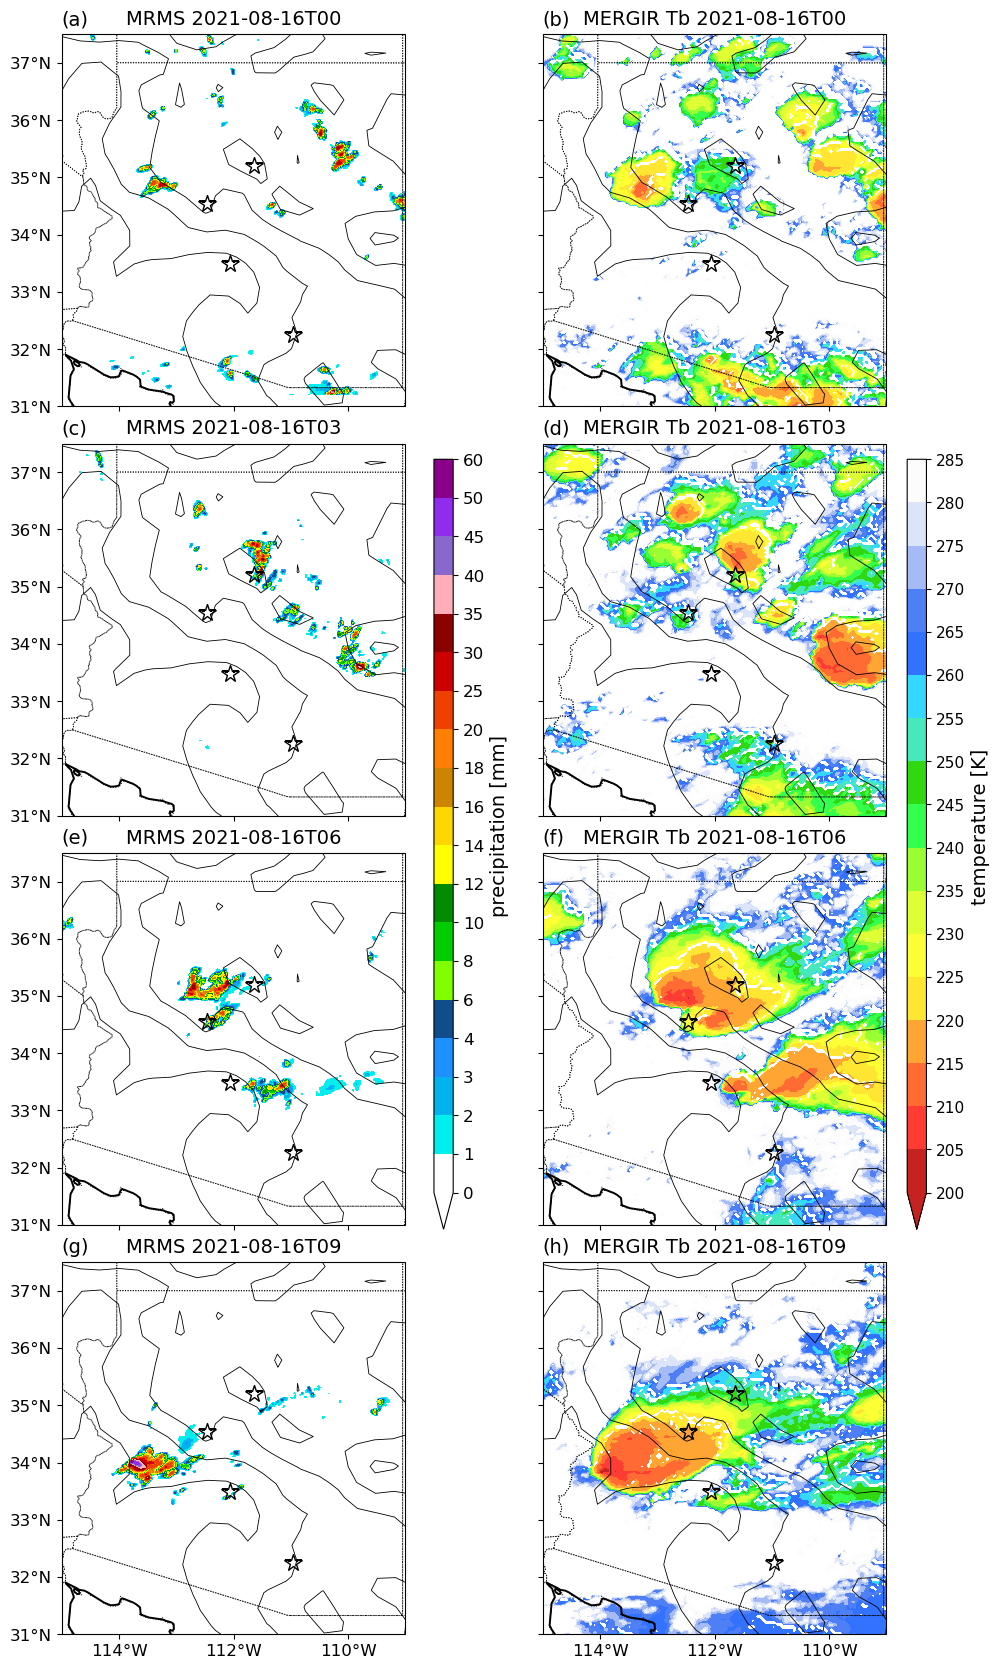

In [11]:
###########################################
# Plot Rain hourly #           
###########################################
alph = ['(a)','(b)','(c)','(d)','(e)','(f)','(g)','(h)']
projection = ccrs.PlateCarree()
fig, axe = plt.subplots(4, 2, figsize=(12, 20),
                                   subplot_kw={'projection': projection})
## AX1
axlist = axe.flatten()
for ax1 in axlist:
    plot_background(ax1)
    dens1 = axlist[0].contourf(xlon_mrms,xlat_mrms,np.squeeze(al_pcp_hr[0,:,:]),
                     var_hr,cmap=precip_hr,norm=adjnorm_hr,extend='min',transform=projection,)
    dens2 = axlist[1].contourf(xlon_merg,xlat_merg,np.squeeze(al_ctt_hr[0,:,:]),
                     varval,cmap=cloud_cmap,norm=adjnorm,extend='min',transform=projection,)
    dens1 = axlist[2].contourf(xlon_mrms,xlat_mrms,np.squeeze(al_pcp_hr[3,:,:]),
                     var_hr,cmap=precip_hr,norm=adjnorm_hr,extend='min',transform=projection,)
    dens2 = axlist[3].contourf(xlon_merg,xlat_merg,np.squeeze(al_ctt_hr[3,:,:]),
                     varval,cmap=cloud_cmap,norm=adjnorm,extend='min',transform=projection,)
    dens1 = axlist[4].contourf(xlon_mrms,xlat_mrms,np.squeeze(al_pcp_hr[6,:,:]),
                     var_hr,cmap=precip_hr,norm=adjnorm_hr,extend='min',transform=projection,)
    dens2 = axlist[5].contourf(xlon_merg,xlat_merg,np.squeeze(al_ctt_hr[6,:,:]),
                     varval,cmap=cloud_cmap,norm=adjnorm,extend='min',transform=projection,)
    dens1 = axlist[6].contourf(xlon_mrms,xlat_mrms,np.squeeze(al_pcp_hr[9,:,:]),
                     var_hr,cmap=precip_hr,norm=adjnorm_hr,extend='min',transform=projection,)
    dens2 = axlist[7].contourf(xlon_merg,xlat_merg,np.squeeze(al_ctt_hr[9,:,:]),
                     varval,cmap=cloud_cmap,norm=adjnorm,extend='min',transform=projection,)
    ## set title
    t0 = axlist[0].set_title('MRMS '+dateList[0],
                            loc='center',pad=7,fontsize=14)
    t1 = axlist[1].set_title('MERGIR Tb '+dateList[0],
                            loc='center',pad=7,fontsize=14)
    t0 = axlist[2].set_title('MRMS '+dateList[3],
                            loc='center',pad=7,fontsize=14)
    t1 = axlist[3].set_title('MERGIR Tb '+dateList[3],
                            loc='center',pad=7,fontsize=14)
    t0 = axlist[4].set_title('MRMS '+dateList[6],
                            loc='center',pad=7,fontsize=14)
    t1 = axlist[5].set_title('MERGIR Tb '+dateList[6],
                            loc='center',pad=7,fontsize=14)
    t0 = axlist[6].set_title('MRMS '+dateList[9],
                            loc='center',pad=7,fontsize=14)
    t1 = axlist[7].set_title('MERGIR Tb '+dateList[9],
                            loc='center',pad=7,fontsize=14)

    for ip in range(len(alph)):
        axlist[ip].set_title(alph[ip],loc='left',pad=7,fontsize=14)

    axlist[0].set_xticklabels([]);axlist[1].set_xticklabels([]);axlist[1].set_yticklabels([]);
    axlist[2].set_xticklabels([]);axlist[3].set_xticklabels([]);axlist[3].set_yticklabels([]);
    axlist[4].set_xticklabels([]);axlist[5].set_xticklabels([]);axlist[5].set_yticklabels([]);
    axlist[7].set_yticklabels([])

#Add precip colorbar
cbar = fig.colorbar(dens1,ticks=var_hr,ax=axe,
                        orientation='vertical',shrink=0.5,aspect=40,pad=0.0,anchor=(-3.6,0.5))
cbar.ax.tick_params(labelsize=12)
cbar.set_label('precipitation [mm]',fontsize=14)
    
cbarm = fig.colorbar(dens2,ticks=varval,ax=axe,
                         orientation='vertical',shrink=0.5,aspect=40,pad=0.0,anchor=(1.6,0.5))
cbarm.ax.tick_params(labelsize=11)
cbarm.set_label('temperature [K]',fontsize=14)

plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.8, 
                    top=0.9, 
                    wspace=0.34, 
                    hspace=0.1)

## SAVE
dir_out = '/secchi/bayu/PLOTS/ARIZONA_PRO/MRMS_MERGIR_ALL/Samples_peak/'
plotfile  = 'Hourly_precip_MRMS_MERGIR_00-03-06-09_UTC.png'
sf = fig.savefig(dir_out+plotfile, dpi=300, bbox_inches='tight')

## CLOSE
plt.show()
plt.close()